In [1]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set() 
import re

In [2]:
#train set(training ml models)
train_data = pd.read_csv('train.csv')
train_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
#test set (to make predictions)
test_data = pd.read_csv("test.csv")
test_data.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [4]:
#test_labels set (evaluating performance)
testlabels_data = pd.read_csv("test_labels.csv")
testlabels_data.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [5]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Test Labels shape:", testlabels_data.shape)

Train shape: (159571, 8)
Test shape: (153164, 2)
Test Labels shape: (153164, 7)


In [6]:
print("\nTrain columns:")
print(train_data.columns)

print("\nTest columns:")
print(test_data.columns)


Train columns:
Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

Test columns:
Index(['id', 'comment_text'], dtype='object')


In [7]:
# train data stats
train_data.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# test data stats
test_data.describe()

,id,comment_text
count,153164,153164
unique,153164,153164
top,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
freq,1,1


In [9]:
# train dataset info
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [10]:
# test dataset info
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


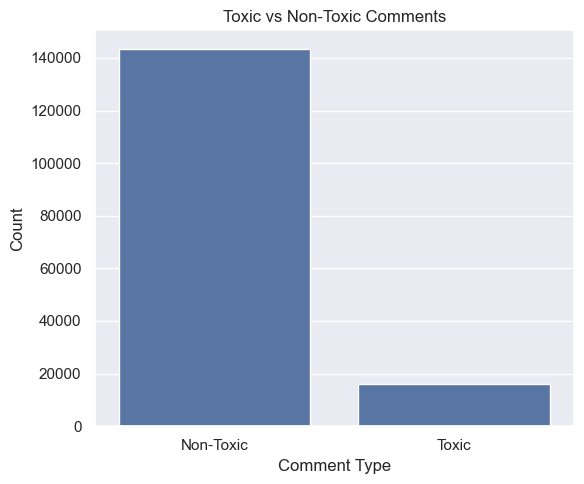

In [11]:
# label columns
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Bar chart: toxic vs non-toxic comments Ctrain set)

train_data["is_toxic_any"] = (train_data[label_cols].sum(axis=1) > 0).astype(int)

toxicity_summary = train_data["is_toxic_any"].value_counts().sort_index()
toxicity_summary.index = ["Non-Toxic", "Toxic"]

plt.figure(figsize=(6, 5))
sb.barplot(x=toxicity_summary.index, y=toxicity_summary.values)
plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

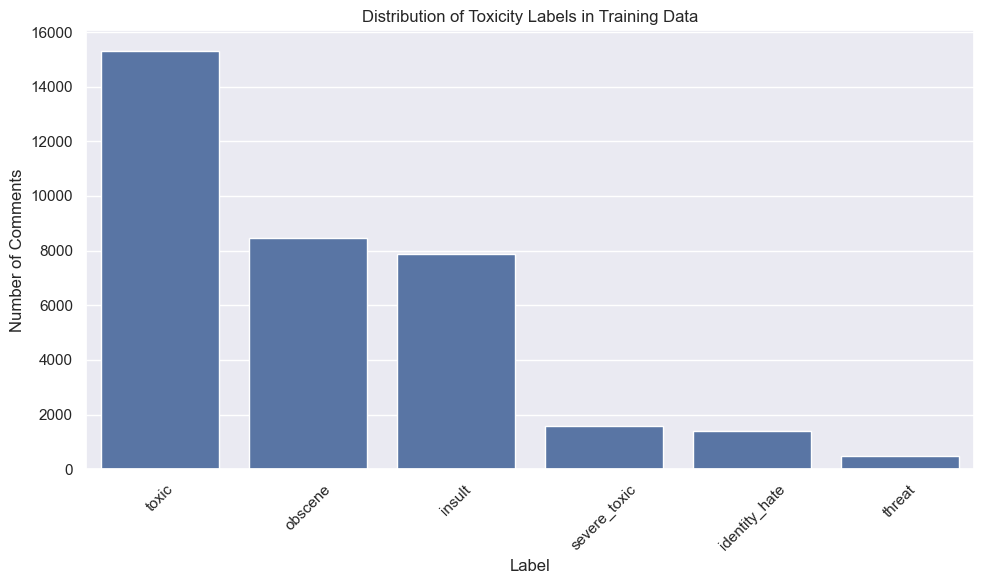

In [12]:
# Bar chart: count of each toxicity label Ctrain set)

label_counts = train_data[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Toxicity Labels in Training Data")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

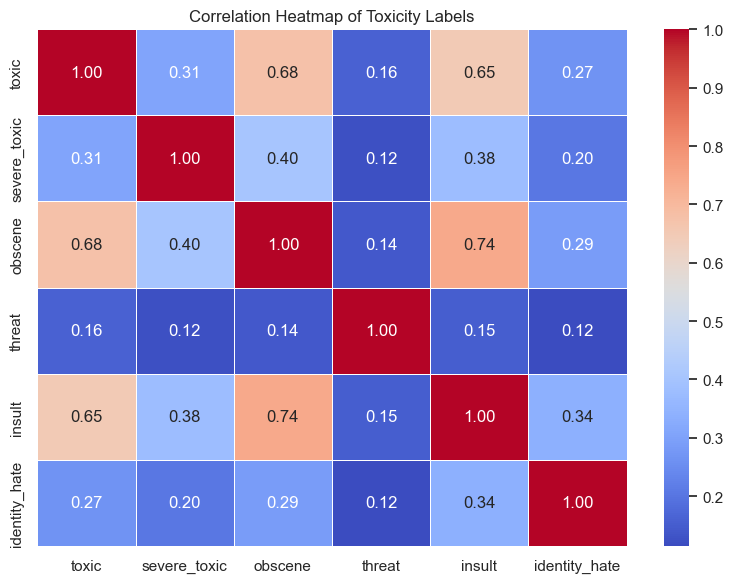

In [13]:
# Heatmap: correlation between toxicity labels Ctrain set)

plt.figure(figsize=(8, 6))
corr_matrix = train_data[label_cols].corr()

sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Toxicity Labels")
plt.tight_layout()
plt.show()

# DATA PREPROCESSING/CLEANING 

- Text Cleaning✔️
- Filling missing values✔️
- TF-IDF with removal of stopwards ✔️ 
- Stemming(impacts TF-IDF performance)❌

In [14]:
#create a text cleaning function to clean raw text

def clean_text(text):
    text = str(text)
    text = text.lower()

    # remove html tags
    text = re.sub(r'<.*?>', ' ', text)

    # expand contractions
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)

    # remove number-containing tokens
    text = re.sub(r'\b\w*\d+\w*\b', ' ', text)

    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
#apply text cleaning on train data
train_data["clean_comment"] = train_data["comment_text"].apply(clean_text)
test_data["clean_comment"] = test_data["comment_text"].apply(clean_text)

In [16]:
#cleaned textual train data
train_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...
2,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...
3,"""\nMore\nI can't make any real suggestions on ...",more i can not make any real suggestions on im...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


In [17]:
#cleaned textual test data
test_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule is more succesful then you wi...
1,== From RfC == \n\n The title is fine as it is...,from rfc the title is fine as it is imo
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton on lapland
3,":If you have a look back at the source, the in...",if you have a look back at the source the info...
4,I don't anonymously edit articles at all.,i do not anonymously edit articles at all
5,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
6,Please do not add nonsense to Wikipedia. Such ...,please do not add nonsense to wikipedia such e...
7,:Dear god this site is horrible.,dear god this site is horrible
8,""" \n Only a fool can believe in such numbers. ...",only a fool can believe in such numbers the co...
9,== Double Redirects == \n\n When fixing double...,double redirects when fixing double redirects ...


In [18]:
#remove null values/missing comments in case of any
train_data.dropna(subset=["clean_comment"])
train_data[train_data["clean_comment"].str.strip() != '']
test_data.dropna(subset=["clean_comment"])
test_data[test_data["clean_comment"].str.strip() != '']

,id,comment_text,clean_comment
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule is more succesful then you wi...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,from rfc the title is fine as it is imo
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton on lapland
3,00017563c3f7919a,":If you have a look back at the source, the in...",if you have a look back at the source the info...
4,00017695ad8997eb,I don't anonymously edit articles at all.,i do not anonymously edit articles at all
...,...,...,...
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu...",i totally agree this stuff is nothing but too ...
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...,throw from out field to home plate does it get...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ...",okinotorishima categories i see your changes a...
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the...",one of the founding nations of the eu germany ...


In [19]:
#Final check for any null/missing values
print("Empty comments after cleaning (train data):",
      (train_data["clean_comment"] == "").sum())
print("Empty comments after cleaning (test data):",
      (test_data["clean_comment"] == "").sum())

Empty comments after cleaning (train data): 11
Empty comments after cleaning (test data): 913


In [20]:
#saving cleaned train textual data in new csv file
train_data.to_csv("train_cleaned.csv", index=False)
test_data.to_csv("test_cleaned.csv", index=False)

In [21]:
#Feature Engineering (train set)

train_data["char_count"] = train_data["clean_comment"].apply(len)   # length features
train_data["word_count"] = train_data["clean_comment"].apply(lambda x: len(x.split()))
train_data["exclamation_count"] = train_data["comment_text"].str.count("!")    # punctuation features
train_data["question_count"] = train_data["comment_text"].str.count(r"\?")
train_data["uppercase_ratio"] = train_data["comment_text"].apply(             # uppercase ratio
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)
#Feature enginering (test set)
test_data["char_count"] = test_data["clean_comment"].apply(len)
test_data["word_count"] = test_data["clean_comment"].apply(lambda x: len(x.split()))
test_data["exclamation_count"] = test_data["comment_text"].str.count("!")
test_data["question_count"] = test_data["comment_text"].str.count(r"\?")
test_data["uppercase_ratio"] = test_data["comment_text"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

In [22]:
#Separation of text and labels for train set to perform tf-idf
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

X = train_data["clean_comment"]   #tf-idf will be only done on comments, not on labels. 
y = train_data[label_cols]
X_test = test_data["clean_comment"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(127656,) (31915,)
(127656, 6) (31915, 6)


In [23]:
#Performing TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
custom_stopwords = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"}

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words=list(custom_stopwords),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'\b[a-zA-Z]{2,}\b'
)

X_train_tfidf = tfidf.fit_transform(X_train) #fits the model and transforms  data
X_val_tfidf = tfidf.transform(X_val) #only transforms into tf-idf values
X_test_tfidf = tfidf.transform(X_test) #only transforms into tf-idf values

In [24]:
#viewing TF-IDF results
print("X_train_tfidf shape:", X_train_tfidf.shape)  
print("X_val_tfidf shape:", X_val_tfidf.shape)  
print("X_test_tfidf shape:", X_test_tfidf.shape)  


print("\nFirst 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])    # features/words/n-grams from train set (these are columns in tf-idf file)
print('\n')
feature_names = tfidf.get_feature_names_out()  # its corresponding tdf-idf numbers for the features
df_tfidf = pd.DataFrame(
    X_train_tfidf[:5].toarray(),   
    columns=feature_names)
print(df_tfidf)

X_train_tfidf shape: (127656, 30000)
X_val_tfidf shape: (31915, 30000)
X_test_tfidf shape: (153164, 30000)

First 20 TF-IDF features:
['aa' 'aap' 'aaron' 'ab' 'aba' 'abandon' 'abandoned' 'abbas' 'abbey'
 'abbott' 'abbreviated' 'abbreviation' 'abbreviations' 'abc' 'abc news'
 'abd' 'abdul' 'abdullah' 'abe' 'abhira']


    aa  aap  aaron   ab  aba  abandon  abandoned  abbas  abbey  abbott  ...  \
0  0.0  0.0    0.0  0.0  0.0      0.0        0.0    0.0    0.0     0.0  ...   
1  0.0  0.0    0.0  0.0  0.0      0.0        0.0    0.0    0.0     0.0  ...   
2  0.0  0.0    0.0  0.0  0.0      0.0        0.0    0.0    0.0     0.0  ...   
3  0.0  0.0    0.0  0.0  0.0      0.0        0.0    0.0    0.0     0.0  ...   
4  0.0  0.0    0.0  0.0  0.0      0.0        0.0    0.0    0.0     0.0  ...   

   zoe  zombie  zone  zones  zoo  zoom  zora   zu  zuck  zuckerberg  
0  0.0     0.0   0.0    0.0  0.0   0.0   0.0  0.0   0.0         0.0  
1  0.0     0.0   0.0    0.0  0.0   0.0   0.0  0.0   0.0         0.

In [25]:
#viewing features with highest tf-idf values
row = 0  # choose a document
feature_names = tfidf.get_feature_names_out()
row_values = X_train_tfidf[row].toarray().flatten()

df = pd.DataFrame({
    'feature': feature_names,
    'tfidf': row_values
})

# show only non-zero values
df = df[df['tfidf'] > 0]

# sort by importance
df = df.sort_values(by='tfidf', ascending=False)
print(df.head(10))

             feature     tfidf
10597  grandma terri  0.552814
10596        grandma  0.527061
26076          terri  0.487311
27022          trash  0.321852
3509            burn  0.187073
10981           hate  0.143210
11101           hell  0.141549


In [26]:
#combine features and tf-idf values into 1 single array (feature engineering)
train_extra = train_data.loc[X_train.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

val_extra = train_data.loc[X_val.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

test_extra = train_data.loc[X_test.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix, hstack

scaler = StandardScaler()

train_extra = scaler.fit_transform(train_extra)
val_extra   = scaler.transform(val_extra)
test_extra  = scaler.transform(test_extra)

X_train_final = hstack([X_train_tfidf, csr_matrix(train_extra)])
X_val_final   = hstack([X_val_tfidf, csr_matrix(val_extra)])
X_test_final  = hstack([X_test_tfidf, csr_matrix(test_extra)])

#### Summary
1. Load data
2. EDA
3. Clean text and remove null values
4. Feature engineering
5. Train/validation split
6. TF-IDF wiht stopword removal
7. Combine features

# MACHINE LEARNING

#### Variables to be used for Logistic Regression
X_train_final, y_train, X_val_final, y_val will be used to train the Logistic Regression model.

X_test_final/test_data will be used for making final predictions and test_labels is for evaluating performance